/tmp/ipykernel_1396/855291773.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2024-01-01', periods=24, freq='M')


        Date       Sales
0 2024-01-31  207.450712
1 2024-02-29  205.926035
2 2024-03-31  225.715328
3 2024-04-30  246.845448
4 2024-05-31  228.487699


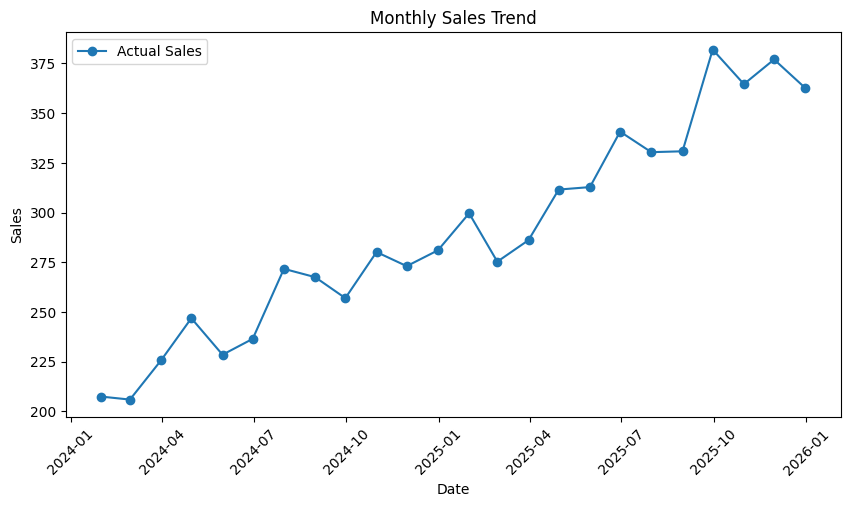

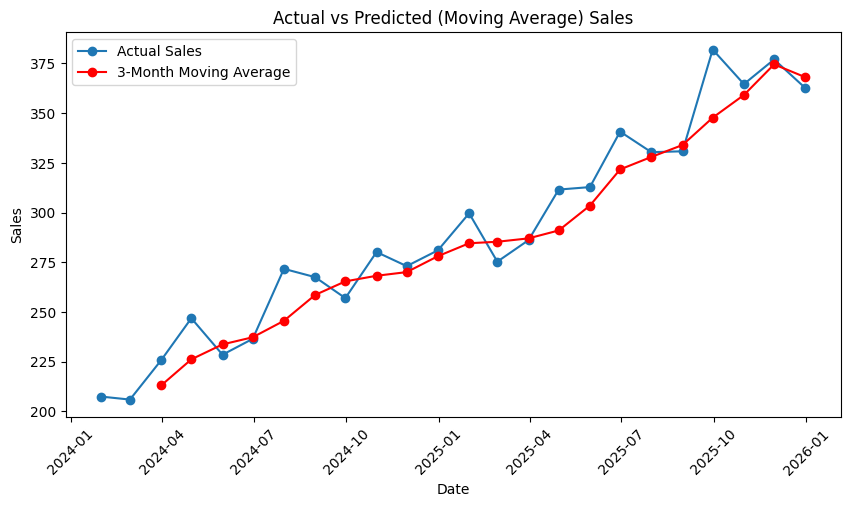

         Date       Sales  Moving_Avg
18 2025-07-31  330.379639  327.966961
19 2025-08-31  330.815444  333.969598
20 2025-09-30  381.984732  347.726605
21 2025-10-31  364.613355  359.137844
22 2025-11-30  377.012923  374.537003
23 2025-12-31  362.628777  368.085019
Mean Absolute Error: 10.40


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a sample sales dataset (monthly sales over 2 years)
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', periods=24, freq='M')
sales = 200 + np.arange(24) * 8 + np.random.normal(0, 15, 24)  # upward trend + noise

sales_df = pd.DataFrame({'Date': dates, 'Sales': sales})
print(sales_df.head())

# 1. Plot the raw sales trend
plt.figure(figsize=(10,5))
plt.plot(sales_df['Date'], sales_df['Sales'], marker='o', label='Actual Sales')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# 2. Predict using Moving Average (window = 3 months)
sales_df['Moving_Avg'] = sales_df['Sales'].rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(sales_df['Date'], sales_df['Sales'], marker='o', label='Actual Sales')
plt.plot(sales_df['Date'], sales_df['Moving_Avg'], marker='o', color='red', label='3-Month Moving Average')
plt.title('Actual vs Predicted (Moving Average) Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# 3. Simple accuracy check — compare last few actual vs moving avg values
comparison = sales_df[['Date', 'Sales', 'Moving_Avg']].tail(6)
print(comparison)

# 4. Calculate error (only where moving average exists)
valid = sales_df.dropna()
mae = np.mean(np.abs(valid['Sales'] - valid['Moving_Avg']))
print(f"Mean Absolute Error: {mae:.2f}")